In [2]:
import yaml
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
from brf_lightning.data import BearingDataModule

In [3]:
cfg_path = Path("configs/bearing/thl/simple_brf.yaml")

with open(cfg_path) as f:
    cfg = yaml.safe_load(f)

data_args = cfg["data"]["init_args"]

In [4]:
dm = BearingDataModule(**data_args)
dm.setup()

train_ds = dm.train_ds
val_ds   = dm.val_ds
test_ds  = dm.test_ds

print(f"Train windows : {len(train_ds)}")
print(f"Val windows   : {len(val_ds)}")
print(f"Test windows  : {len(test_ds)}")


Train windows : 837
Val windows   : 99
Test windows  : 99


In [5]:
bucket_counts = defaultdict(int)
for ds in [train_ds, val_ds, test_ds]:
    for x, lbl, spd in ds:
        bucket_counts[(int(lbl), float(spd))] += 1

print("\nBalanced bucket counts (label, speed) → windows")
for k in sorted(bucket_counts):
    print(f"{k}: {bucket_counts[k]}")



Balanced bucket counts (label, speed) → windows
(0, 10.0): 115
(0, 20.0): 115
(0, 30.0): 115
(1, 10.0): 115
(1, 20.0): 115
(1, 30.0): 115
(2, 10.0): 115
(2, 20.0): 115
(2, 30.0): 115


In [6]:
all_means, all_stds = [], []
for ds in [train_ds, val_ds, test_ds]:
    for x, _, _ in ds:
        all_means.append(float(x.mean()))
        all_stds.append(float(x.std()))
print(f"\nOverall mean  (expect ≈0): {sum(all_means)/len(all_means):.4f}")
print(f"Overall std   (expect ≈1): {sum(all_stds)/len(all_stds):.4f}")


Overall mean  (expect ≈0): -0.0000
Overall std   (expect ≈1): 0.6791


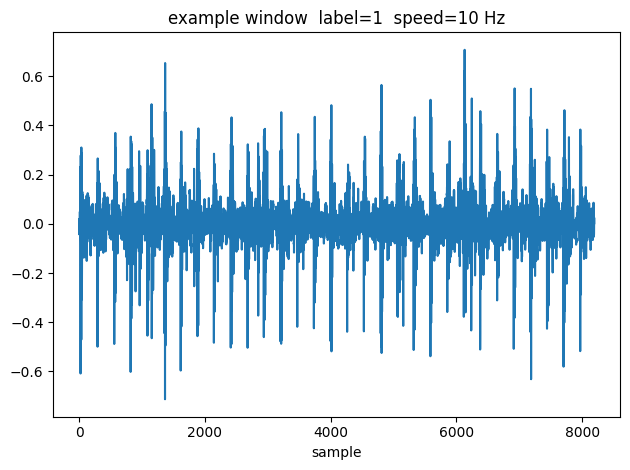

In [8]:
x, lbl, spd = train_ds[0]
plt.figure()
plt.plot(x.squeeze().numpy())
plt.title(f"example window  label={int(lbl)}  speed={float(spd):.0f} Hz")
plt.xlabel("sample")
plt.tight_layout()
plt.show()

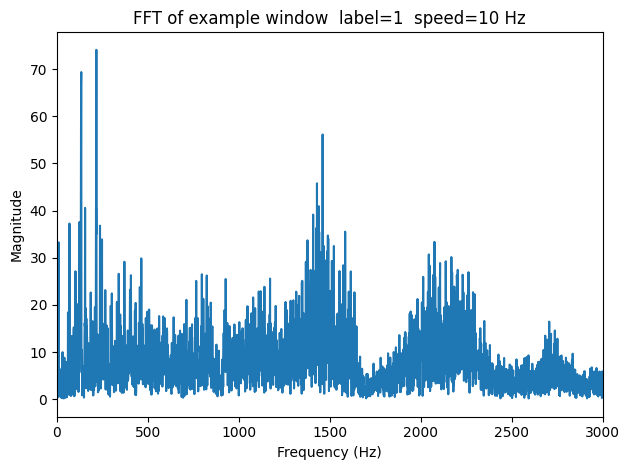

In [12]:
# calculate the fft and plot the spectrum
import numpy as np
def plot_fft(x, title=None):
    n = len(x)
    freq = np.fft.fftfreq(n, d=1/8192)  # assuming a sampling rate of 8192 Hz
    fft_values = np.fft.fft(x)
    plt.figure()
    plt.plot(freq[:n//2], np.abs(fft_values)[:n//2])
    if title:
        plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, 3000)  # limit x-axis to 500 Hz for better visibility
    plt.tight_layout()
    plt.show()

# Plot the FFT of the first example window
x, lbl, spd = train_ds[0]
plot_fft(x.squeeze().numpy(), title=f"FFT of example window  label={int(lbl)}  speed={float(spd):.0f} Hz")